## **OIBSIP Task 2**

 **Car Price Prediction using Machine Learning**

Author: Muhammad Danish

Internship: Oasis Infobyte Data Science

**Car Price Prediction using Machine Learning**

**Objective**
Predict the selling price of a used car using machine learning regression models.

**Technologies Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

**Import Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [2]:
#load dataset

df = pd.read_csv('../dataset/car data.csv')

# show head

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [3]:
# last rows 10

print(df.tail(10))

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
291     brio  2015           5.40           6.10       31427    Petrol   
292     jazz  2016           6.40           8.40       12000    Petrol   
293     city  2010           3.25           9.90       38000    Petrol   
294    amaze  2014           3.75           6.80       33019    Petrol   
295     city  2015           8.55          13.09       60076    Diesel   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
291      Dealer       Manual      0  
292      Dealer       Manual      0  
293      Dealer       Manual      0  
294      Dealer       Manual     

In [4]:
#shape of dataset

print(df.shape)

(301, 9)


In [5]:
# info of dataset

print(df.info())

# describe of dataset

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
None
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     50

**anylsis of data**

In [7]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())
print(df['Owner'].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
[0 1 3]


**missing values**

In [9]:
# missing values in each column
print("null values in each column:")
print(df.isnull().sum())

null values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [12]:
#duplicate values in dataset
print("duplicate values in dataset:")
print(df.duplicated().sum())

duplicate values in dataset:
2


**Feature Engineering**

In [16]:
current_year = 2026

df['car_age'] = current_year - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,car_age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [20]:
# extract brand

df['brand'] = df["Car_Name"].str.split().str[0]

print(df.head(10))
print("\n")
print(df.tail(10))

        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0           ritz  2014           3.35           5.59       27000    Petrol   
1            sx4  2013           4.75           9.54       43000    Diesel   
2           ciaz  2017           7.25           9.85        6900    Petrol   
3        wagon r  2011           2.85           4.15        5200    Petrol   
4          swift  2014           4.60           6.87       42450    Diesel   
5  vitara brezza  2018           9.25           9.83        2071    Diesel   
6           ciaz  2015           6.75           8.12       18796    Petrol   
7        s cross  2015           6.50           8.61       33429    Diesel   
8           ciaz  2016           8.75           8.89       20273    Diesel   
9           ciaz  2015           7.45           8.92       42367    Diesel   

  Seller_Type Transmission  Owner  car_age   brand  
0      Dealer       Manual      0       12    ritz  
1      Dealer       Manual      0  

In [21]:
#drop the columns which are not required for prediction

df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,car_age,brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


**Exploratory Data Analysis (EDA)**

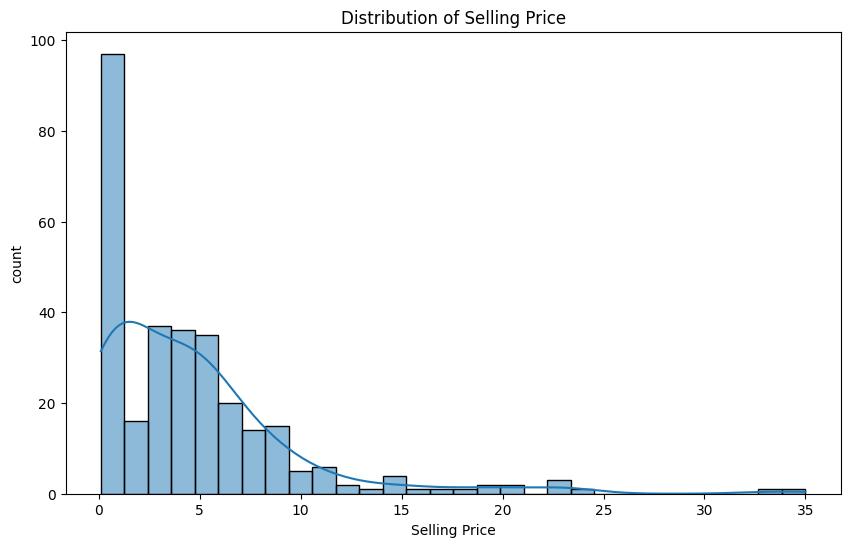

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price') 
plt.ylabel('count')
plt.show()

**Price vs Fuel Type**

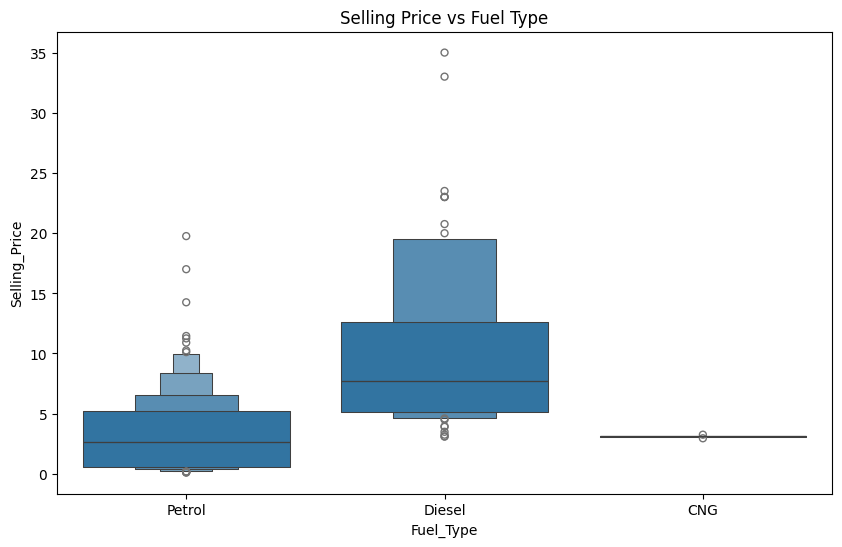

In [26]:
plt.figure(figsize=(10, 6))
sns.boxenplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Selling Price vs Fuel Type')
plt.show()

**Price vs Car Age**

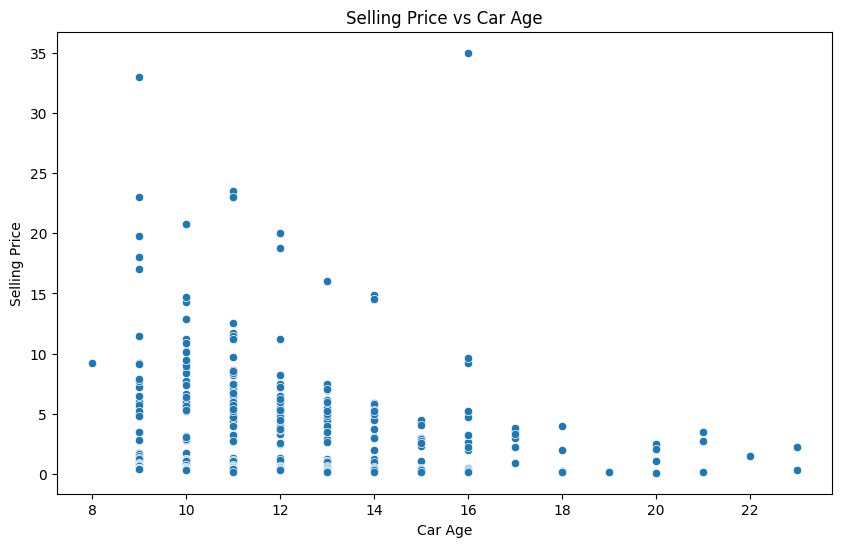

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='Selling_Price', data=df)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')
plt.show()

**Feature Encoding**

In [42]:
x = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

**Identify Columns**

In [44]:
categorical_columns = x.select_dtypes(include='object').columns

numerical_columns = x.select_dtypes(exclude='object').columns

**One-Hot Encoder**

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)

**Correlation Heatmap**

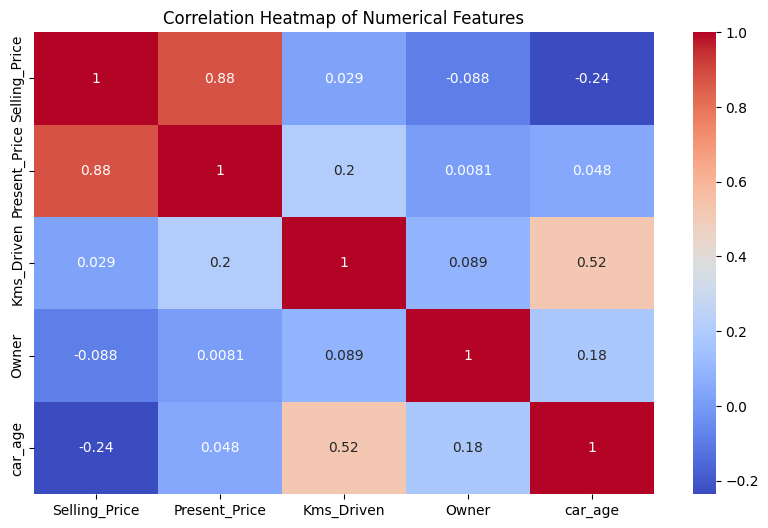

In [33]:
#numerical_cols  only

plt.figure(figsize=(10, 6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

**Train-Test Split**
    

In [51]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

**Linear Regression**

In [52]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(x_train, y_train)

linear_model_predictions = linear_model.predict(x_test)

print("Linear odel predictions:")
print(linear_model_predictions)

Linear odel predictions:
[ 3.19735471e+00  8.60219245e+00  6.25855286e+00 -1.45800002e+00
  7.75793696e+00  7.19043710e+00  1.31987114e+00  5.17323282e-01
  1.66497416e+00  7.04526910e+00  8.69566392e+00  5.77390960e-01
  8.98168935e+00  4.14491087e+00  6.71150263e+00  2.86763363e+00
  4.98527673e-01  9.37811853e+00  1.52656973e+00  2.43223202e+00
  1.94788456e-01  8.27063547e+00  6.45521031e+00  2.65471996e+00
  7.58340114e-01  3.73543177e+00  5.72191994e+00  2.14511749e+00
  2.11919284e+00  1.73537891e+00  7.12871303e-01  9.15347708e+00
 -6.57750399e-01  2.09975519e+00  8.09646449e+00  4.27900941e+00
  5.92002112e+00  6.21614219e+00  2.92624209e+00  6.61908963e+00
  5.47096731e+00  3.51337573e+00  4.14680590e+00  4.37970490e-01
  6.93377430e+00  2.45295784e-01  7.70236074e+00  1.02783052e+01
  3.35257875e+00  5.06342175e+00  7.43860893e+00  2.16821865e+00
  2.15809285e+01  1.84084299e+01  7.28785636e+00  1.05759840e+01
  4.50284613e+00  9.06881053e+00  2.39912329e+00  8.06307478e+00


**Random Forest Regressor**

In [53]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, random_state=42
        ))
])

rf_model.fit(x_train, y_train)

rf_model_predictions = rf_model.predict(x_test)

**Model Evaluation**

**linear regression**

In [54]:
linear_mae = mean_absolute_error(y_test, linear_model_predictions)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_model_predictions))

linear_r2 = r2_score(y_test, linear_model_predictions)

In [55]:
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {linear_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {linear_rmse:.2f}")
print(f"R-squared (R2): {linear_r2:.2f}")

Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 1.12
Root Mean Squared Error (RMSE): 1.74
R-squared (R2): 0.87


In [56]:
#accuracy of linear regression model
linear_accuracy = linear_model.score(x_test, y_test)
print(f"Accuracy: {linear_accuracy:.2f}")

Accuracy: 0.87


**Random Forest Regressor**

In [58]:
rf_mae = mean_absolute_error(y_test, rf_model_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_model_predictions))

rf_r2 = r2_score(y_test, rf_model_predictions)

In [59]:
print("Random Forest Model Evaluation:")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"R-squared (R2): {rf_r2:.2f}")

Random Forest Model Evaluation:
Mean Absolute Error (MAE): 0.60
Root Mean Squared Error (RMSE): 0.87
R-squared (R2): 0.97


In [60]:
accuracy_rf = rf_model.score(x_test, y_test)
print(f"Random Forest Model Accuracy: {accuracy_rf:.2f}")

Random Forest Model Accuracy: 0.97


**Comparison Table**

In [61]:
result = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest'],
    'MAE' : [linear_mae, rf_mae],
    'RMSE' : [linear_rmse, rf_rmse],
    'R2' : [linear_r2, rf_r2],
})

result

,Model,MAE,RMSE,R2
0,Linear Regression,1.117474,1.737823,0.868897
1,Random Forest,0.599864,0.874600,0.966794


**Feature Importance**

In [62]:
encoder = rf_model.named_steps['preprocessor']

encoded_features = encoder.get_feature_names_out()

rf = rf_model.named_steps['model']

importance = pd.DataFrame({
    'Feature': encoded_features,
    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
    ) 

importance.head(10)

,Feature,Importance
44,remainder__Present_Price,0.869612
47,remainder__car_age,0.061950
45,remainder__Kms_Driven,0.029165
3,cat__Transmission_Manual,0.008946
36,cat__brand_land,0.006153
29,cat__brand_fortuner,0.005736
21,cat__brand_city,0.003159
34,cat__brand_innova,0.002934
0,cat__Fuel_Type_Diesel,0.002807
22,cat__brand_corolla,0.001905


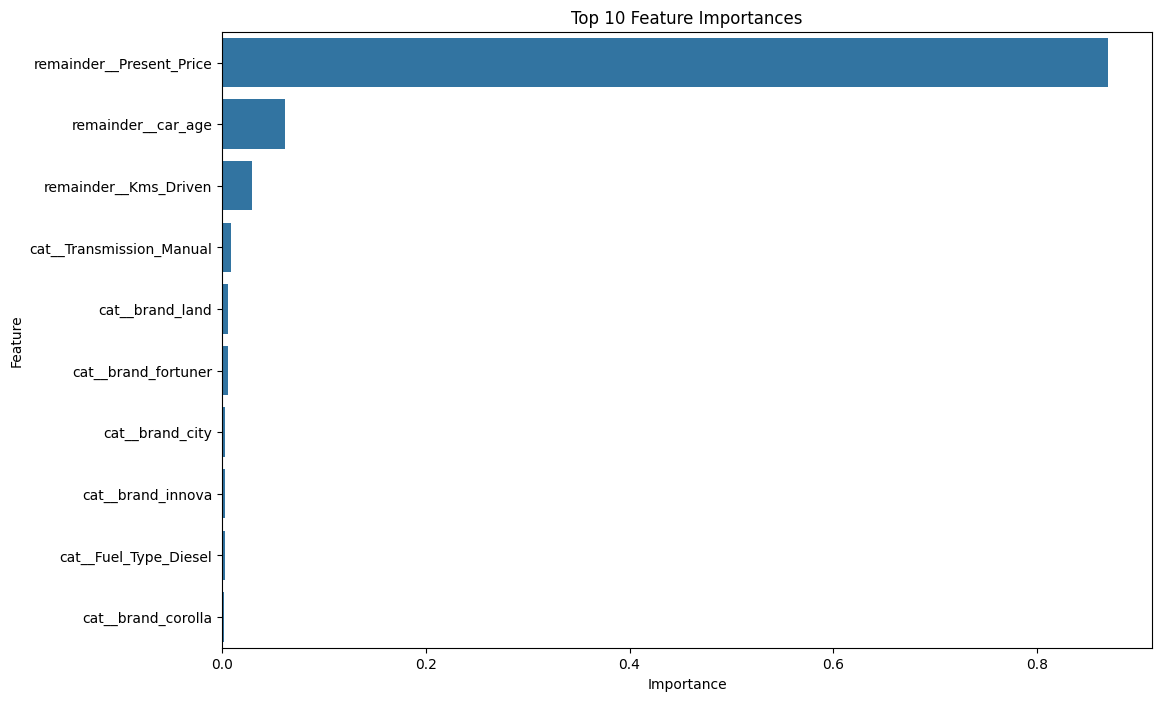

In [63]:
#plot feature importance

plt.figure(figsize=(12, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Save Best Model**

In [65]:
joblib.dump(rf_model, '../outputs/best_model.pkl')

['../outputs/best_model.pkl']

**Prediction Example**

In [70]:
sample = x_test.iloc[[0]]

prediction = rf_model.predict(sample)

print(sample)
print(f"Prediction: {prediction[0]}")

     Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner  \
177           0.57       24000    Petrol  Individual    Automatic      0   

     car_age  brand  
177       10  Honda  
Prediction: 0.44049999999999995


**Save Predictions**

In [73]:
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_model_predictions
})

predictions.to_csv("../outputs/predictions.csv", index=False)

**Save Evaluation Results**

In [75]:
result.to_csv("../outputs/model_metrics.csv", index=False)

## Conclusion

- Built a machine learning model to predict used car selling prices.
- Performed data cleaning and feature engineering.
- Conducted exploratory data analysis.
- Trained and compared Linear Regression and Random Forest Regressor.
- Evaluated models using MAE, RMSE, and R² score.
- Random Forest Regressor achieved the best overall performance and was saved as the final model.